In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [10]:
data = pd.read_json("..\data\json_data\country_ingredients.json").T.to_csv("..\data\json_data\country_ingredients.csv")

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Admin\AppData\Local\Temp\ipykernel_7716\3987819974.py:1: SyntaxWarning: invalid escape sequence '\d'
  data = pd.read_json("..\data\json_data\country_ingredients.json").T.to_csv("..\data\json_data\country_ingredients.csv")
C:\Users\Admin\AppData\Local\Temp\ipykernel_7716\3987819974.py:1: SyntaxWarning: invalid escape sequence '\d'
  data = pd.read_json("..\data\json_data\country_ingredients.json").T.to_csv("..\data\json_data\country_ingredients.csv")


In [15]:
import pandas as pd
import numpy as np
import streamlit as st
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from collections import defaultdict
import plotly.express as px

In [19]:
df

,sub_region,ingredient,frequency,ingredient_encoded,sub_region_encoded
0,hickory_wood_chunks,Australia and New Zealand,0,0,1176
1,red_new_potatoes,Australia and New Zealand,0,0,1855
2,linguiça_sausage,Australia and New Zealand,0,0,1374
3,beef_top_sirloin,Australia and New Zealand,0,0,321
4,cooking_grits,Australia and New Zealand,0,0,701
...,...,...,...,...,...
55687,crusty_Italian_bread,Western Europe,0,20,758
55688,Polish_sausage_links,Western Europe,0,20,124
55689,shell_prawns,Western Europe,0,20,2030
55690,loaf,Western Europe,5,20,1388


In [24]:
ingred['sub_region'] = ingred.index
ingred = ingred.melt(id_vars=['sub_region'], var_name='ingredient', value_name='frequency')

df = ingred

# Encode
ingredient_encoder = LabelEncoder()
df['ingredient_encoded'] = ingredient_encoder.fit_transform(df['ingredient'])

subregion_encoder = LabelEncoder()
df['sub_region_encoded'] = subregion_encoder.fit_transform(df['sub_region'])

X = df[['ingredient_encoded', 'frequency']]
y = df['sub_region_encoded']

scaler = StandardScaler()
X['frequency'] = scaler.fit_transform(X[['frequency']])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

y_pred_labels = subregion_encoder.inverse_transform(y_pred)
y_test_labels = subregion_encoder.inverse_transform(y_test)

for i in range(5):
    print(f"Predicted: {y_pred_labels[i]}, Actual: {y_test_labels[i]}")

def predict_subregion_for_ingredient(ingredient_name, frequency_value=1):
    ingredient_encoded = ingredient_encoder.transform([ingredient_name])[0]
    print(f"Encoded ingredient: {ingredient_encoded}")
    frequency_scaled = scaler.transform([[frequency_value]])[0][0]
    X_input = [[ingredient_encoded, frequency_scaled]]
    pred_encoded = model.predict(X_input)[0]
    sub_region = subregion_encoder.inverse_transform([pred_encoded])[0]
    return sub_region

uniq_ingredients = pd.read_json("data/json_data/country_ingredients.json").index.tolist()

tmp = [predict_subregion_for_ingredient(i, frequency_value=1) for i in uniq_ingredients]

ValueError: value_name (frequency) cannot match an element in the DataFrame columns.

In [ ]:
di = {
  "ingred": uniq_ingredients,
  "sub_region": tmp
}

In [18]:
uniq_ingredients

['hickory_wood_chunks',
 'red_new_potatoes',
 'linguiça_sausage',
 'beef_top_sirloin',
 'cooking_grits',
 'blueberries',
 'free_plain_style_yogurt',
 'backfat',
 'Corona_beans',
 'chicken',
 'japones',
 'pitted_dates',
 'cilantro_sprigs',
 'tortilla',
 'sliced_lengthwise',
 'sliced_bamboo_shoots',
 'mashed_potatoes',
 'vegan_tortillas',
 'russet_potato',
 'beets',
 'curry_leaves',
 'grenadine_syrup',
 'sharp_Cheddar_cheese',
 'mustard_powder',
 'crust_pie_pastry',
 'raw_pistachios',
 'furikake_seasoning',
 'ginger_root',
 'egg_whites',
 'adobo_sazon_criollo',
 'beef_soup_bones',
 'chop_slices',
 'paprika',
 'choy_stalks',
 'processed_cheese_food',
 'palm_sugar',
 'bell_pepper',
 'ground_almond_meal',
 'parsnips',
 'black_cumin_seeds',
 'top',
 'sliced_jalapeno_pepper',
 'jaggery',
 'seashell_pasta',
 'matzo',
 'black_sesame_paste',
 'pita_chips',
 'veal_breast',
 'blood_oranges',
 'pitted_olives',
 'almond_slivers',
 'grain_white_rice',
 'seafood_mix',
 'oxtail',
 'aluminum_foil',
 'ba

In [12]:
pd.read_json("..\data\json_data\country_ingredients.json")

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Admin\AppData\Local\Temp\ipykernel_7716\2321998130.py:1: SyntaxWarning: invalid escape sequence '\d'
  pd.read_json("..\data\json_data\country_ingredients.json")


,Australia and New Zealand,Caribbean,Central America,Central Asia,Eastern Africa,Eastern Asia,Eastern Europe,Middle Africa,Northern Africa,Northern America,...,Polynesia,South America,South-Eastern Asia,Southeast Asia,Southern Africa,Southern Asia,Southern Europe,Western Africa,Western Asia,Western Europe
hickory_wood_chunks,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
red_new_potatoes,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
linguiça_sausage,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,0
beef_top_sirloin,0,0,0,0,0,3,0,0,0,0,...,0,1,3,1,0,0,0,0,0,1
cooking_grits,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
crusty_Italian_bread,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
Polish_sausage_links,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
shell_prawns,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
loaf,0,1,2,0,0,0,0,0,0,2,...,0,0,0,0,0,0,1,0,0,5


In [11]:
pd.read_csv("..\data\json_data\country_ingredients.csv")

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Admin\AppData\Local\Temp\ipykernel_7716\3872687428.py:1: SyntaxWarning: invalid escape sequence '\d'
  pd.read_csv("..\data\json_data\country_ingredients.csv")


,Unnamed: 0,hickory_wood_chunks,red_new_potatoes,linguiça_sausage,beef_top_sirloin,cooking_grits,blueberries,free_plain_style_yogurt,backfat,Corona_beans,...,pepperoncini_juice,optional_sugar,chicken_bones,Salt,char_siu,crusty_Italian_bread,Polish_sausage_links,shell_prawns,loaf,slices_onion
0,Australia and New Zealand,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Caribbean,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0
2,Central America,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2,0
3,Central Asia,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Eastern Africa,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
5,Eastern Asia,0,0,0,3,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
6,Eastern Europe,0,1,0,0,0,0,0,0,0,...,0,0,0,1,0,0,1,0,0,0
7,Middle Africa,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,Northern Africa,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,Northern America,0,0,0,0,1,1,0,0,0,...,1,0,0,0,0,1,0,0,2,1


In [3]:
df = pd.read_csv('../data/cleaned_recipes_v2.csv',index_col=0)

In [7]:
# Split the data into features (X) and target (y)
X = df.drop(columns=['title', 'steps','cuisine','continent','sub_region','ingredients'], axis=1)
y = df['continent']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
# Fill NaN values with 0
X_train = np.nan_to_num(X_train)
X_test = np.nan_to_num(X_test)

X = np.nan_to_num(X)


In [19]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [21]:
y_pred = knn.predict(X_test)

In [23]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.4135240572171652


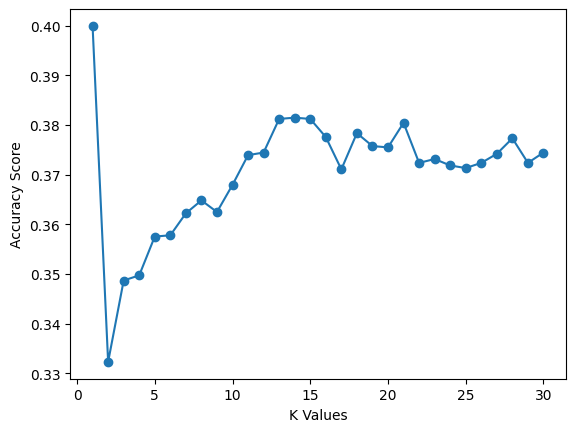

In [24]:
from sklearn.model_selection import cross_val_score

k_values = range(1, 31)
scores = []

for k in k_values:
  knn = KNeighborsClassifier(n_neighbors=k)
  score = cross_val_score(knn, X, y, cv=5)
  scores.append(score.mean())

# Plot the results
import matplotlib.pyplot as plt
plt.plot(k_values, scores, marker='o')
plt.xlabel('K Values')
plt.ylabel('Accuracy Score')
plt.show()